# Exercice 1. Decouvrez les blocs de construction du RL
## Projet Eagle-1 · AstroDynamics · OpenClassrooms
**Auteur :** Rafael Cerezo Martin

**Date :** Juin 2026

---

### Objectif
Se familiariser avec le cycle fondamental :

> **Observation -> Action -> Recompense**

1. Creer et explorer `CartPole-v1`
2. Implementer une politique **aleatoire** sur 10 episodes
3. Visualiser avec des graphiques et une animation en temps reel

---
## [Cellule] Installation et verification des versions

In [1]:
# !pip install gymnasium stable-baselines3 -q

# ============================================================
# ENVIRONNEMENT — détection automatique Colab / local
# ============================================================
import sys                                     # gestion du chemin Python
import os                                      # opérations système
from pathlib import Path                       # chemins portables

print(sys.version)

try:
    import google.colab                        # disponible uniquement sur Colab
    BASE = Path(
        '/content/drive/MyDrive/OpenClassrooms'
        '/M11_Entrainez_votre_agent_RL/m11_ocr'
    )
except ImportError:
    BASE = Path().resolve().parent             # notebooks/ → m11_ocr/

CORE   = BASE / 'core'                        # modules utilitaires du projet
MODELS = BASE / 'models'                      # modèles entraînés sauvegardés
MODELS.mkdir(exist_ok=True)                   # créer si absent

sys.path.insert(0, str(CORE))                 # rendre les modules importables

# ── Chemins fichiers ──────────────────────────────────────────
sb3_path    = MODELS / 'dqn_cartpole_sb3'    # modèle SB3 (sans extension)
best_policy = MODELS / 'best_policy_net.pth' # meilleurs poids policy_net

# ============================================================
# MODULES CORE DU PROJET
# ============================================================
from env_utils import make_env                 # création d'environnements Gym
from env_utils import inspect_env              # inspection des espaces
from env_utils import run_n_random_episodes    # épisodes politique aléatoire

from metrics   import compute_stats            # statistiques descriptives
from metrics   import print_stats              # affichage formaté des stats
from metrics   import moving_average           # moyenne glissante
from metrics   import success_rate             # taux de réussite

from viz_utils import plot_episode_metrics     # courbes récompense/pas
from viz_utils import plot_reward_distribution # histogramme des récompenses
from viz_utils import animate_episode_with_metrics  # animation avec métriques
from viz_utils import show_env_frame           # affichage frame statique
from viz_utils import plot_q_directional_map   # carte directionnelle Q-table

# ============================================================
# BIBLIOTHÈQUES SCIENTIFIQUES
# ============================================================
import numpy              as np               # calcul vectoriel et matriciel
import random                                 # génération aléatoire Python

# ============================================================
# DEEP LEARNING — PyTorch
# ============================================================
import torch                                  # framework deep learning
import torch.nn           as nn               # couches et modules neuronaux
import torch.nn.functional as F               # fonctions d'activation
import torch.optim        as optim            # optimiseurs (Adam, SGD…)

# ============================================================
# ENVIRONNEMENTS DE SIMULATION — Gymnasium
# ============================================================
import gymnasium          as gym              # environnements RL standardisés

# ============================================================
# VISUALISATION — Matplotlib
# ============================================================
%matplotlib inline
import matplotlib                             # configuration du backend
import matplotlib.pyplot   as plt             # tracé de graphiques
import matplotlib.patches  as patches         # formes géométriques (FancyBox…)
import matplotlib.animation as animation      # animations frame par frame
import matplotlib.gridspec  as gridspec       # mise en page multi-panneaux

# ============================================================
# UTILITAIRES PYTHON
# ============================================================
from collections      import deque            # buffer circulaire (replay)
from IPython.display  import HTML, display    # affichage HTML dans le notebook

# ============================================================
# VÉRIFICATION DE L'ENVIRONNEMENT
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED      = 42                                # graine reproductibilité
SEED_EVAL = 99                                # graine évaluation distincte
WINDOW    = 50                                # fenêtre moyenne glissante

print("\n============================================================")
print("VÉRIFICATION DE L'ENVIRONNEMENT")
print("============================================================")
print(f"  Gymnasium...........: {gym.__version__}")
print(f"  PyTorch.............: {torch.__version__}")
print(f"  NumPy...............: {np.__version__}")
print(f"  GPU disponible......: {torch.cuda.is_available()}")
print(f"  Device..............: {DEVICE}")
print(f"  Backend matplotlib..: {matplotlib.get_backend()}")
print("============================================================")
print(f"  BASE................: {BASE}")
print(f"  CORE................: {CORE}")
print(f"  MODELS..............: {MODELS}")
print(f"  CORE existe.........: {CORE.exists()}")
print("============================================================")

# ── Test rapide de l'environnement ───────────────────────────
_env = make_env('CartPole-v1', seed=SEED)
print(f"  CartPole-v1.........: OK"
      f"  obs_dim={_env.observation_space.shape[0]}"
      f"  n_actions={_env.action_space.n}")
_env.close()
print("============================================================")

3.12.12 (main, Jan 14 2026, 19:30:21) [MSC v.1944 64 bit (AMD64)]

VÉRIFICATION DE L'ENVIRONNEMENT
  Gymnasium...........: 1.3.0
  PyTorch.............: 2.12.0+cpu
  NumPy...............: 2.4.6
  GPU disponible......: False
  Device..............: cpu
  Backend matplotlib..: inline
  BASE................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr
  CORE................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\core
  MODELS..............: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models
  CORE existe.........: True
  CartPole-v1.........: OK  obs_dim=4  n_actions=2


## Fichiers Auxiliers. Modules core

---
### Cellule 2a — Module env_utils.py (architecture hexagonale)

In [2]:
# %%writefile env_utils.py

# env_utils.py
# Utilitaires environnements. Reutilisable Ex.1-3 + Eagle-1

import gymnasium as gym
import numpy     as np


def make_env(env_id, render_mode=None, seed=42):
    # Cree une instance Gymnasium avec graine pour reproductibilite
    env = gym.make(env_id, render_mode=render_mode)
    env.reset(seed=seed)
    return env


def inspect_env(env):
    # Affiche un rapport complet sur les espaces d observation et d action
    print('=' * 60)
    print('RAPPORT D INSPECTION DE L ENVIRONNEMENT')
    print('=' * 60)
    obs_space = env.observation_space
    print('\n-- ESPACE D OBSERVATION -------------------------')
    print(f'  Type................: {type(obs_space).__name__}')
    if isinstance(obs_space, gym.spaces.Box):
        print(f'  Shape...............: {obs_space.shape}')
        print(f'  dtype...............: {obs_space.dtype}')
        print(f'  Borne inferieure....: {obs_space.low}')
        print(f'  Borne superieure....: {obs_space.high}')
    elif isinstance(obs_space, gym.spaces.Discrete):
        print(f'  N etats.............: {obs_space.n}')
    print(f'  Exemple aleatoire...: {obs_space.sample()}')

    act_space = env.action_space
    print('\n-- ESPACE D ACTION --------------------------------')
    print(f'  Type................: {type(act_space).__name__}')
    if isinstance(act_space, gym.spaces.Discrete):
        print(f'  N actions...........: {act_space.n}')
        print(f'  Actions dispo.......: {list(range(act_space.n))}')
    elif isinstance(act_space, gym.spaces.Box):
        print(f'  Shape...............: {act_space.shape}')
        print(f'  Borne inferieure....: {act_space.low}')
        print(f'  Borne superieure....: {act_space.high}')
    print(f'  Exemple aleatoire...: {act_space.sample()}')
    print('=' * 60)


def run_random_episode(env):
    # Execute un episode complet avec politique aleatoire
    # Retourne total_reward (float) et n_steps (int)
    obs, info    = env.reset()
    total_reward = 0.0
    n_steps      = 0
    terminated   = False
    truncated    = False
    while not (terminated or truncated):
        # Selectionner une action uniformement aleatoire
        action                              = env.action_space.sample()
        # Appliquer l action (API Gymnasium : 5 valeurs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        n_steps      += 1
    return total_reward, n_steps


def run_n_random_episodes(env_id, n_episodes=10, seed=42, verbose=True):
    # Execute n episodes aleatoires et collecte les metriques
    env     = make_env(env_id, seed=seed)
    rewards = []
    steps   = []
    if verbose:
        print(f'\nPolitique ALEATOIRE -- {n_episodes} episodes -- {env_id}')
        print('-' * 50)
    for ep in range(n_episodes):
        total_reward, n_steps = run_random_episode(env)
        rewards.append(total_reward)
        steps.append(n_steps)
        if verbose:
            print(f'  Episode {ep+1:2d}.........: recompense = {total_reward:7.1f}'
                  f'  |  pas = {n_steps:4d}')
    env.close()
    if verbose:
        print('-' * 50)
        print(f'  Moyenne recompense..: {np.mean(rewards):.2f}'
              f'  +-  {np.std(rewards):.2f}')
        print(f'  Moyenne pas.........: {np.mean(steps):.1f}')
    return rewards, steps




```
# Tiene formato de código
```

### Cellule 2b — Module metrics.py

In [3]:
# %%writefile metrics.py

# metrics.py
# Statistiques et metriques. Reutilisable Ex.1-3 + Eagle-1

import numpy as np


def compute_stats(rewards, steps=None):
    # Statistiques descriptives d une liste de recompenses
    rewards = np.array(rewards)
    stats   = {
        'n_episodes' : len(rewards),
        'mean'       : float(np.mean(rewards)),
        'std'        : float(np.std(rewards)),
        'min'        : float(np.min(rewards)),
        'max'        : float(np.max(rewards)),
        'median'     : float(np.median(rewards)),
        'q25'        : float(np.percentile(rewards, 25)),
        'q75'        : float(np.percentile(rewards, 75)),
    }
    if steps is not None:
        steps               = np.array(steps)
        stats['mean_steps'] = float(np.mean(steps))
        stats['std_steps']  = float(np.std(steps))
        stats['max_steps']  = float(np.max(steps))
    return stats


def print_stats(stats, label='Statistiques'):
    # Rapport formate des statistiques d episodes
    print(f'\n{"=" * 50}')
    print(f'  {label}')
    print(f'{"=" * 50}')
    print(f'  Episodes............: {stats["n_episodes"]}')
    print(f'  Recompense moyenne..: {stats["mean"]:7.2f}  +-  {stats["std"]:.2f}')
    print(f'  Recompense min/max..: {stats["min"]:7.2f}  /   {stats["max"]:.2f}')
    print(f'  Mediane.............: {stats["median"]:7.2f}')
    print(f'  Q25 / Q75...........: {stats["q25"]:7.2f}  /   {stats["q75"]:.2f}')
    if 'mean_steps' in stats:
        print(f'  Pas moyens..........: {stats["mean_steps"]:7.1f}  +-  {stats["std_steps"]:.1f}')
        print(f'  Pas maximum.........: {stats["max_steps"]:7.0f}')
    print(f'{"=" * 50}')


def moving_average(values, window=50):
    # Moyenne glissante pour lisser les courbes de recompense
    values = np.array(values)
    return np.convolve(values, np.ones(window) / window, mode='valid')


def success_rate(rewards, threshold=1.0):
    # Taux d episodes au-dessus d un seuil
    # FrozenLake : threshold=1.0 / Eagle-1 : threshold=200
    rewards = np.array(rewards)
    return float(np.mean(rewards >= threshold))


[texto del enlace](https://)## Cellule 2c — Module viz_utils.py

In [4]:
# %%writefile viz_utils.py

# viz_utils.py
# Visualisations. Reutilisable Ex.1-3 + Eagle-1

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec  as gridspec
import gymnasium            as gym
from   IPython.display      import HTML


def plot_episode_metrics(rewards, steps, title='Politique Aleatoire'):
    # Deux graphiques cote a cote : recompense et pas par episode
    episodes  = list(range(1, len(rewards) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1 = axes[0]
    ax1.plot(episodes, rewards, color='steelblue', alpha=0.6,
             linewidth=1.5, label='Recompense par episode')
    window = min(10, len(rewards))
    if len(rewards) >= window:
        rolling = np.convolve(rewards,
                              np.ones(window)/window, mode='valid')
        ax1.plot(range(window, len(rewards)+1), rolling,
                 color='darkblue', linewidth=2,
                 label=f'Moyenne glissante ({window} ep.)')
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Recompense totale')
    ax1.set_title('Recompense par episode')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(episodes, steps, color='darkorange', alpha=0.6,
             linewidth=1.5, label='Pas par episode')
    if len(steps) >= window:
        rs = np.convolve(steps, np.ones(window)/window, mode='valid')
        ax2.plot(range(window, len(steps)+1), rs,
                 color='saddlebrown', linewidth=2,
                 label=f'Moyenne glissante ({window} ep.)')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Nombre de pas')
    ax2.set_title('Duree des episodes (pas)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_reward_distribution(rewards, env_id=''):
    # Histogramme de distribution des recompenses
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(rewards, bins=20, color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(rewards), color='red',
               linestyle='--', linewidth=1.5,
               label=f'Moyenne : {np.mean(rewards):.1f}')
    ax.axvline(np.median(rewards), color='orange',
               linestyle='--', linewidth=1.5,
               label=f'Mediane : {np.median(rewards):.1f}')
    ax.set_xlabel('Recompense totale')
    ax.set_ylabel('Frequence')
    ax.set_title(f'Distribution des recompenses -- {env_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_env_frame(env_id, seed=42):
    # Affiche un frame de l etat initial de l environnement
    env = gym.make(env_id, render_mode='rgb_array')
    env.reset(seed=seed)
    frame = env.render()
    env.close()
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(frame)
    ax.axis('off')
    ax.set_title(f'Etat initial -- {env_id}', fontsize=12)
    plt.tight_layout()
    plt.show()


def animate_episode_with_metrics(env_id, policy_fn=None,
                                   seed=42, max_steps=300,
                                   title='Episode en cours'):
    # Anime un episode : rendu visuel (gauche) + deux graphiques (droite)
    # Graphique haut  : recompense PAR PAS (pas cumulee)
    # Graphique bas   : nombre de pas ecoules
    # Retourne HTML affichable dans Colab via display()
    env          = gym.make(env_id, render_mode='rgb_array')
    obs, _       = env.reset(seed=seed)
    frames       = []
    rewards_live = []    # recompense a chaque pas (pas cumulee)
    steps_live   = []    # numero de pas courant
    terminated   = False
    truncated    = False
    step         = 0

    #while not (terminated or truncated) and step < max_steps:
    while not (terminated or truncated):
        # Capturer le frame visuel avant l action
        frame  = env.render()
        frames.append(frame)
        # Choisir l action selon la politique ou aleatoirement
        action = policy_fn(obs) if policy_fn is not None \
                 else env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        step += 1
        # Stocker la recompense du PAS (pas cumulee)
        rewards_live.append(reward)
        steps_live.append(step)

    env.close()

    # ── Construire la figure : rendu | graphiques ─────────────
    fig = plt.figure(figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Mise en page : 50% rendu | 50% deux graphiques superposes
    gs       = gridspec.GridSpec(2, 2,
                                  width_ratios=[1, 1],
                                  height_ratios=[1, 1],
                                  figure=fig)
    ax_env   = fig.add_subplot(gs[:, 0])   # colonne gauche entiere
    ax_r     = fig.add_subplot(gs[0, 1])   # haut droite : recompense
    ax_s     = fig.add_subplot(gs[1, 1])   # bas droite  : pas

    ax_env.axis('off')
    img      = ax_env.imshow(frames[0])

    # ── Graphique 1 : recompense par pas ──────────────────────
    line_r,  = ax_r.plot([], [], color='steelblue',
                          linewidth=1.5, label='Recompense / pas')
    point_r, = ax_r.plot([], [], 'o', color='steelblue', markersize=5)
    ax_r.set_xlim(0, len(frames) + 1)
    # CartPole donne +1 a chaque pas -> plage fixe [0, 1.5]
    r_min = min(rewards_live) - 0.2
    r_max = max(rewards_live) + 0.2
    ax_r.set_ylim(r_min, r_max)
    ax_r.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax_r.set_xlabel('Pas de temps', fontsize=9)
    ax_r.set_ylabel('Recompense', fontsize=9)
    ax_r.set_title('Recompense par pas', fontsize=10)
    ax_r.legend(fontsize=8)
    ax_r.grid(True, alpha=0.3)

    # ── Graphique 2 : nombre de pas ecoules ───────────────────
    line_s,  = ax_s.plot([], [], color='darkorange',
                          linewidth=1.5, label='Pas ecoules')
    point_s, = ax_s.plot([], [], 'o', color='darkorange', markersize=5)
    ax_s.set_xlim(0, len(frames) + 1)
    ax_s.set_ylim(0, len(frames) + 5)
    ax_s.set_xlabel('Pas de temps', fontsize=9)
    ax_s.set_ylabel('Pas total', fontsize=9)
    ax_s.set_title('Nombre de pas ecoules', fontsize=10)
    ax_s.legend(fontsize=8)
    ax_s.grid(True, alpha=0.3)

    # Texte de resume en bas du rendu
    txt = ax_env.text(
        0.02, 0.04, '', transform=ax_env.transAxes,
        fontsize=9, color='white',
        bbox=dict(facecolor='black', alpha=0.5, pad=3),
        verticalalignment='bottom')

    plt.tight_layout()

    # ── Mise a jour frame par frame ───────────────────────────
    def update(i):
        # Mettre a jour le rendu visuel
        img.set_data(frames[i])

        xs = list(range(1, i + 2))

        # Graphique 1 : recompense du pas courant
        ys_r = rewards_live[:i + 1]
        line_r.set_data(xs, ys_r)
        point_r.set_data([xs[-1]], [ys_r[-1]])

        # Graphique 2 : nombre de pas ecoules
        ys_s = steps_live[:i + 1]
        line_s.set_data(xs, ys_s)
        point_s.set_data([xs[-1]], [ys_s[-1]])

        # Texte de resume sur le rendu
        txt.set_text(
            f'Pas : {steps_live[i]}  |  R : {rewards_live[i]:.1f}')

        return img, line_r, point_r, line_s, point_s, txt

    anim = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=50, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


### Cellule 2d — Verification et chargement des modules

In [5]:
import os
#for f in ['env_utils.py', 'metrics.py', 'viz_utils.py']:
#    size = os.path.getsize(f)
#    print(f'  {f:<20}: {size:>5} octets  OK')

from env_utils import make_env, inspect_env, run_n_random_episodes
from viz_utils import (plot_episode_metrics, plot_reward_distribution,
                        animate_episode_with_metrics, show_env_frame)
from metrics   import compute_stats, print_stats

print('\nModules core charges avec succes.')


Modules core charges avec succes.


---
## Etape 1. Creer et explorer CartPole-v1

Inspection des deux espaces fondamentaux :
- **Observation** : 4 flottants continus (`Box`) — ce que l agent voit
- **Action** : 2 actions discretes (`Discrete`) — ce que l agent peut faire

In [6]:
# Creer l environnement pour inspection (sans rendu — plus rapide)
env = make_env('CartPole-v1', render_mode=None, seed=42)

# Rapport complet sur les espaces
inspect_env(env)

env.close()

RAPPORT D INSPECTION DE L ENVIRONNEMENT

-- ESPACE D OBSERVATION -------------------------
  Type................: Box
  Shape...............: (4,)
  dtype...............: float32
  Borne inferieure....: [-4.8               -inf -0.41887903        -inf]
  Borne superieure....: [4.8               inf 0.41887903        inf]
  Exemple aleatoire...: [-3.334259    0.37139282 -0.23520589 -0.6734223 ]

-- ESPACE D ACTION --------------------------------
  Type................: Discrete
  N actions...........: 2
  Actions dispo.......: [0, 1]
  Exemple aleatoire...: 1


In [7]:
# ============================================================
# Démonstration explicite de .sample()
# ============================================================
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = make_env('CartPole-v1', seed=42)

# ── .sample() sur les deux espaces ───────────────────────────
obs_sample    = env.observation_space.sample()
action_sample = env.action_space.sample()

print("env.observation_space.sample()  →")
print(f"  obs[0]  x  position......: {obs_sample[0]:+.4f}  m")
print(f"  obs[1]  ẋ  vitesse........: {obs_sample[1]:+.4f}  m/s")
print(f"  obs[2]  θ  angle..........: {obs_sample[2]:+.4f}  rad")
print(f"  obs[3]  θ̇  vit.angulaire..: {obs_sample[3]:+.4f}  rad/s")
print()
print(f"env.action_space.sample()  →  {action_sample}"
      f"  ({'← gauche' if action_sample==0 else '→ droite'})")

env.close()

env.observation_space.sample()  →
  obs[0]  x  position......: +3.6975  m
  obs[1]  ẋ  vitesse........: +0.2704  m/s
  obs[2]  θ  angle..........: +0.3618  rad
  obs[3]  θ̇  vit.angulaire..: +0.2498  rad/s

env.action_space.sample()  →  1  (→ droite)


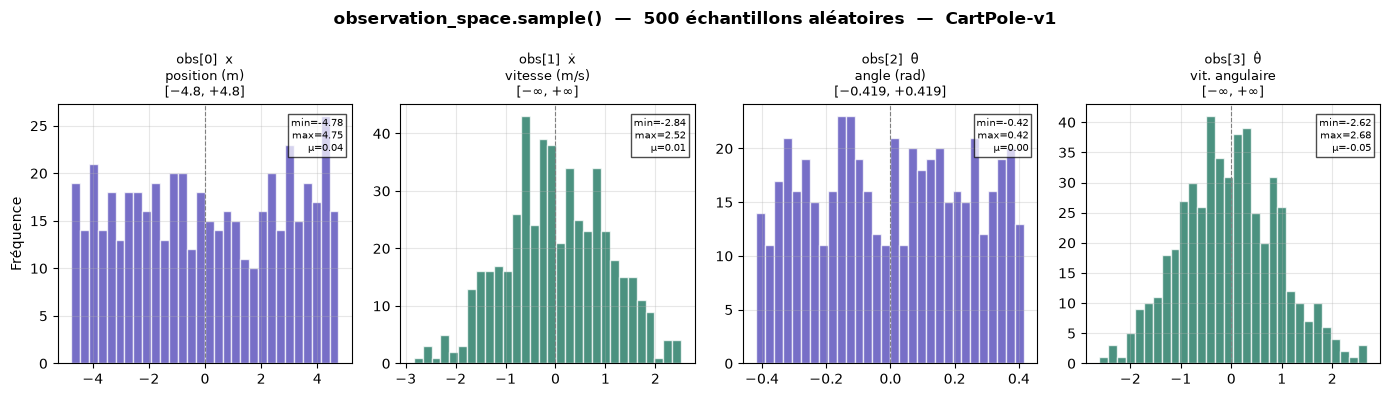

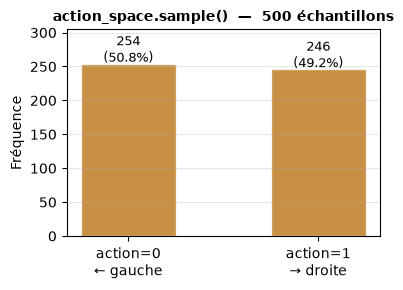

In [8]:
# ============================================================
# Visualisation : 500 samples de l'observation space
# ============================================================
env = make_env('CartPole-v1', seed=42)

N = 500
samples = np.array([env.observation_space.sample() for _ in range(N)])
env.close()

labels  = [
    "obs[0]  x\nposition (m)\n[−4.8, +4.8]",
    "obs[1]  ẋ\nvitesse (m/s)\n[−∞, +∞]",
    "obs[2]  θ\nangle (rad)\n[−0.419, +0.419]",
    "obs[3]  θ̇\nvit. angulaire\n[−∞, +∞]",
]
colors = ["#4A3FB5", "#0F6E56", "#4A3FB5", "#0F6E56"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle(
    f"observation_space.sample()  —  {N} échantillons aléatoires  —  CartPole-v1",
    fontsize=12, fontweight='bold')

for i, ax in enumerate(axes):
    ax.hist(samples[:, i], bins=30,
            color=colors[i], alpha=0.75, edgecolor='white')
    ax.set_title(labels[i], fontsize=9)
    ax.set_ylabel("Fréquence" if i == 0 else "")
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.grid(True, alpha=0.3)
    # stats
    ax.text(0.97, 0.95,
            f"min={samples[:,i].min():.2f}\n"
            f"max={samples[:,i].max():.2f}\n"
            f"μ={samples[:,i].mean():.2f}",
            transform=ax.transAxes,
            fontsize=7.5, ha='right', va='top',
            bbox=dict(fc='white', alpha=0.7, pad=2))

plt.tight_layout()
plt.show()

# ── Action space : comptage des 2 actions ────────────────────
env2 = make_env('CartPole-v1', seed=42)
act_samples = [env2.action_space.sample() for _ in range(N)]
env2.close()

fig2, ax2 = plt.subplots(figsize=(4, 3))
counts = [act_samples.count(0), act_samples.count(1)]
ax2.bar(["action=0\n← gauche", "action=1\n→ droite"],
        counts, color=["#BA7517", "#BA7517"],
        alpha=0.8, edgecolor='white', width=0.5)
ax2.set_title(f"action_space.sample()  —  {N} échantillons",
              fontsize=10, fontweight='bold')
ax2.set_ylabel("Fréquence")
for i, v in enumerate(counts):
    ax2.text(i, v+3, f"{v}\n({v/N*100:.1f}%)",
             ha='center', fontsize=9)
ax2.set_ylim(0, max(counts)*1.2)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 🕵🏻‍♂️ Interpretation: Espace d observation et d action

| Index | Variable | Description | Plage |
|-------|----------|-------------|-------|
| `obs[0]` | Position du chariot | Position horizontale | [-2.4, 2.4] |
| `obs[1]` | Vitesse du chariot | Vitesse lineaire | [-inf, +inf] |
| `obs[2]` | Angle du mat | Inclinaison | [-0.21, 0.21] rad |
| `obs[3]` | Vitesse angulaire | Rotation du mat | [-inf, +inf] |

**Actions :** `0` = gauche  ·  `1` = droite

> **Point de vigilance :** `Box` (continu) — Q-table impossible — DQN (Ex.3)  
> `FrozenLake` a un espace `Discrete` — Q-table possible (Ex.2)

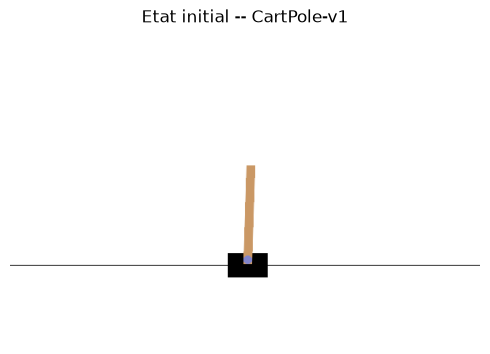


-- CYCLE RL -- 1 PAS DE TEMPS --
  Observation initiale : [-0.04058227  0.04756223  0.02611397  0.02860643]
    obs[0] position....: -0.0406
    obs[1] vitesse.....: 0.0476
    obs[2] angle.......: 0.0261 rad
    obs[3] vel.angul...: 0.0286

  Action choisie: 1 (droite)

  Nouvelle observation..: [-0.03963102  0.24230015  0.0266861  -0.25572422]
  Recompense............: 1.0
  Termine (chute).......: False
  Tronque (limite)......: False
  Done (combine)........: False


In [9]:
# Frame initial de l environnement
show_env_frame('CartPole-v1', seed=42)

# Demonstration manuelle du cycle RL pour 1 pas de temps
env       = make_env('CartPole-v1', render_mode=None, seed=42)
obs, info = env.reset()

print('\n-- CYCLE RL -- 1 PAS DE TEMPS --')
print(f'  Observation initiale : {obs}')
print(f'    obs[0] position....: {obs[0]:.4f}')
print(f'    obs[1] vitesse.....: {obs[1]:.4f}')
print(f'    obs[2] angle.......: {obs[2]:.4f} rad')
print(f'    obs[3] vel.angul...: {obs[3]:.4f}')

# Selectionner une action aleatoire
action = env.action_space.sample()
print(f"\n  Action choisie: {action} ({'gauche' if action==0 else 'droite'})")

# Appliquer l action -- API Gymnasium moderne (5 valeurs)
obs_new, reward, terminated, truncated, info = env.step(action)

print(f'\n  Nouvelle observation..: {obs_new}')
print(f'  Recompense............: {reward}')
print(f'  Termine (chute).......: {terminated}')
print(f'  Tronque (limite)......: {truncated}')
print(f'  Done (combine)........: {terminated or truncated}')

env.close()

---
## Etape 2. Politique aleatoire 

Agent **entierement aleatoire** — aucune connaissance de l environnement.  
C est notre **baseline** : tout agent entraine doit faire mieux.

### [Cellule] 🔍 Evaluation (10 episodes)

In [10]:
# 10 episodes avec politique aleatoire
rewards_10, steps_10 = run_n_random_episodes(
    env_id     = 'CartPole-v1',
    n_episodes = 10,
    seed       = 42,
    verbose    = True
)


Politique ALEATOIRE -- 10 episodes -- CartPole-v1
--------------------------------------------------
  Episode  1.........: recompense =    14.0  |  pas =   14
  Episode  2.........: recompense =    20.0  |  pas =   20
  Episode  3.........: recompense =    11.0  |  pas =   11
  Episode  4.........: recompense =    28.0  |  pas =   28
  Episode  5.........: recompense =    23.0  |  pas =   23
  Episode  6.........: recompense =    15.0  |  pas =   15
  Episode  7.........: recompense =    18.0  |  pas =   18
  Episode  8.........: recompense =    14.0  |  pas =   14
  Episode  9.........: recompense =    15.0  |  pas =   15
  Episode 10.........: recompense =    29.0  |  pas =   29
--------------------------------------------------
  Moyenne recompense..: 18.70  +-  5.87
  Moyenne pas.........: 18.7



  Politique Aleatoire -- 10 episodes -- CartPole-v1
  Episodes............: 10
  Recompense moyenne..:   18.70  +-  5.87
  Recompense min/max..:   11.00  /   29.00
  Mediane.............:   16.50
  Q25 / Q75...........:   14.25  /   22.25
  Pas moyens..........:    18.7  +-  5.9
  Pas maximum.........:      29


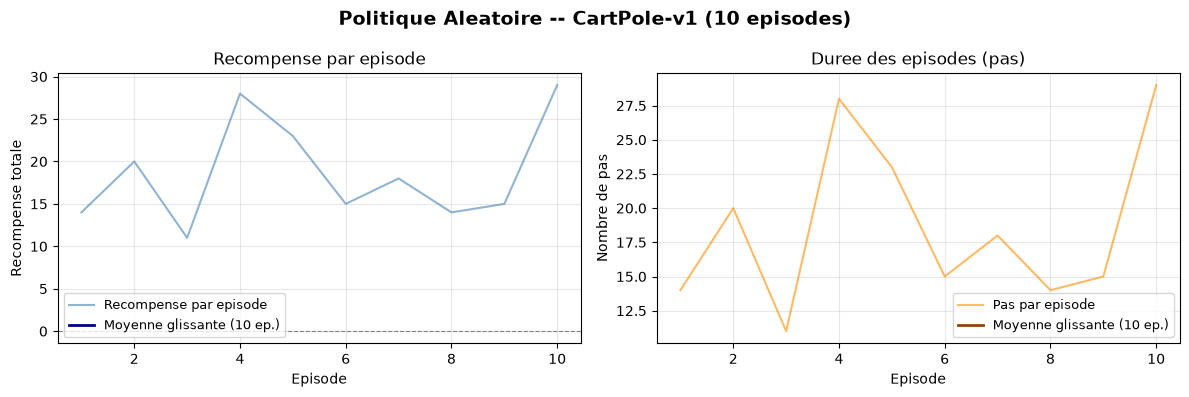

In [11]:
# Statistiques + graphiques sur 10 episodes
stats_10 = compute_stats(rewards_10, steps_10)
print_stats(stats_10,
            label='Politique Aleatoire -- 10 episodes -- CartPole-v1')

plot_episode_metrics(
    rewards_10, steps_10,
    title='Politique Aleatoire -- CartPole-v1 (10 episodes)'
)

### 🕵🏻‍♂️ Interpretation (10 episodes)

- **Variance tres elevee** : chaque episode dure entre 10 et 150 pas selon la chance
- **Recompense = nombre de pas** dans CartPole (+1 par pas ou le mat reste debout)
- 10 episodes insuffisants pour une estimation fiable — passage a 100

### [Cellule] 🔍 Evaluation (100 episodes)


  Politique Aleatoire -- 100 episodes -- CartPole-v1
  Episodes............: 100
  Recompense moyenne..:   22.39  +-  11.84
  Recompense min/max..:    9.00  /   64.00
  Mediane.............:   19.00
  Q25 / Q75...........:   14.00  /   25.25
  Pas moyens..........:    22.4  +-  11.8
  Pas maximum.........:      64


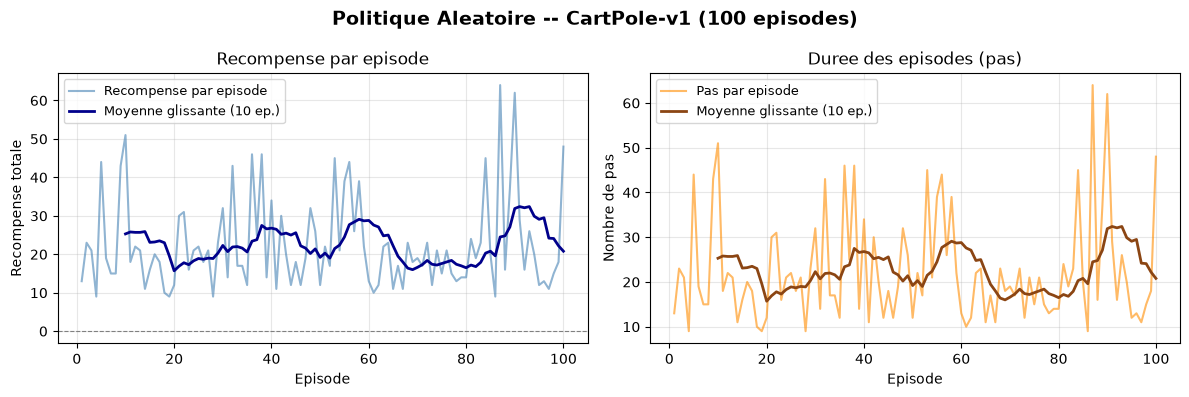

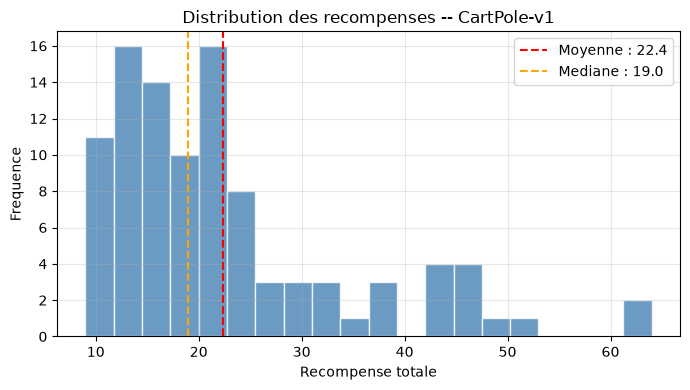

In [12]:
# 100 episodes pour une vue statistique plus robuste
rewards_100, steps_100 = run_n_random_episodes(
    env_id     = 'CartPole-v1',
    n_episodes = 100,
    seed       = 42,
    verbose    = False
)

stats_100 = compute_stats(rewards_100, steps_100)
print_stats(stats_100,
            label='Politique Aleatoire -- 100 episodes -- CartPole-v1')

plot_episode_metrics(
    rewards_100, steps_100,
    title='Politique Aleatoire -- CartPole-v1 (100 episodes)'
)

plot_reward_distribution(rewards_100, env_id='CartPole-v1')

### 🕵🏻‍♂️ Interpretation (100 episodes)

| Politique | Recompense moyenne attendue |
|-----------|-----------------------------|
| Aleatoire (notre baseline) | ~20-80 pts |
| DQN entraine (Exercice 3) | ~200-400 pts |
| PPO optimise (Eagle-1) | **>= 200 pts** (critere de succes) |
| Optimal | 500 pts (maximum possible) |

---
### [Cellule] 🎥 Animation. Environnement + graphique en temps reel

In [13]:
# Animation : rendu visuel (gauche) + recompense cumulee (droite)
# Les deux panneaux se mettent a jour a chaque pas de temps
anim = animate_episode_with_metrics(
    env_id    = 'CartPole-v1',
    policy_fn = None,      # None = politique aleatoire integree
    seed      = 42,
    max_steps = 600,
    title     = 'CartPole-v1 -- Politique Aleatoire -- Temps Reel'
)

anim_html = HTML(anim.to_html5_video())

display(anim_html)

### [Cellule] 💾 Animation. Sauvegarder 

In [14]:
# ── Sauvegarder la vidéo ─────────────────────────────────────
from datetime import datetime

ts       = datetime.now().strftime("%y%m%d_%H%M%S")   # 250619_143022
nom_anim = f"ex1_{ts}_cartpole_politique_aleatoire"
anim_path_mp4 = MODELS / f"{nom_anim}.mp4"
anim_path_gif = MODELS / f"{nom_anim}.gif"

try:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter(fps=30, bitrate=1800)
    anim.save(str(anim_path_mp4), writer=writer)
    print(f"  MP4 sauvegardé.....: {anim_path_mp4.name}")
    print(f"  Taille..............: "
          f"{anim_path_mp4.stat().st_size // 1024} KB")
except Exception as e:
    from matplotlib.animation import PillowWriter
    print(f"  FFMpeg non disponible : {e}")
    writer = PillowWriter(fps=25)
    anim.save(str(anim_path_gif), writer=writer)
    print(f"  GIF sauvegardé.....: {anim_path_gif.name}")
    print(f"  Taille..............: "
          f"{anim_path_gif.stat().st_size // 1024} KB")

  MP4 sauvegardé.....: ex1_260620_113900_cartpole_politique_aleatoire.mp4
  Taille..............: 65 KB


---
## Etape 3. Comparaison des environnements

### [Cellule] 🔍 COMPARAISON DES ESPACES

In [15]:
envs_to_compare = [
    ('CartPole-v1',    'Box(4,)     -- Exercice 1 : politique aleatoire + DQN (Ex.3)'),
    ('FrozenLake-v1',  'Discrete(16)-- Exercice 2 : Q-table'),
    ('LunarLander-v3', 'Box(8,)     -- Mission Eagle-1 : PPO/DQN'),
]

print('\n-- COMPARAISON DES ESPACES --')
print(f"{'Environnement':<20} {'Obs. Space':<20} {'Action Space':<15} {'Exercice'}")
print('-' * 75)

for env_id, note in envs_to_compare:
    env_tmp  = gym.make(env_id)
    obs_t    = type(env_tmp.observation_space).__name__
    act_t    = type(env_tmp.action_space).__name__
    obs_info = (f'{obs_t}{env_tmp.observation_space.shape}'
                if hasattr(env_tmp.observation_space, 'shape')
                else f'{obs_t}({env_tmp.observation_space.n})')
    act_info = (f'{act_t}({env_tmp.action_space.n})'
                if hasattr(env_tmp.action_space, 'n')
                else f'{act_t}{env_tmp.action_space.shape}')
    print(f'  {env_id:<18} {obs_info:<20} {act_info:<15}  <- {note}')
    env_tmp.close()

print('-' * 75)
print('\nConclusion :')
print('  CartPole    -> Ex.1 politique aleatoire (baseline)')
print('                Ex.3 DQN (reseau neuronal)')
print('  FrozenLake  -> Ex.2 Q-table (espace discret fini)')
print('  LunarLander -> Mission Eagle-1 : PPO/DQN')


-- COMPARAISON DES ESPACES --
Environnement        Obs. Space           Action Space    Exercice
---------------------------------------------------------------------------
  CartPole-v1        Box(4,)              Discrete(2)      <- Box(4,)     -- Exercice 1 : politique aleatoire + DQN (Ex.3)
  FrozenLake-v1      Discrete()           Discrete(4)      <- Discrete(16)-- Exercice 2 : Q-table
  LunarLander-v3     Box(8,)              Discrete(4)      <- Box(8,)     -- Mission Eagle-1 : PPO/DQN
---------------------------------------------------------------------------

Conclusion :
  CartPole    -> Ex.1 politique aleatoire (baseline)
                Ex.3 DQN (reseau neuronal)
  FrozenLake  -> Ex.2 Q-table (espace discret fini)
  LunarLander -> Mission Eagle-1 : PPO/DQN


---
## Conclusion — Exercice 1

**Ce que nous avons appris :**

1. **Cycle RL fondamental** : `observation -> action -> recompense -> nouvel etat`
2. **Espaces Gymnasium** : `Box` (continu) vs `Discrete` (discret)
3. **Baseline aleatoire** : ~20-80 pts sur CartPole
4. **API Gymnasium moderne** :
```python
obs, info = env.reset()                                      # 2 valeurs
obs, reward, terminated, truncated, info = env.step(action)  # 5 valeurs
done = terminated or truncated                               # combiner
```

**Prochaines etapes :**
- Exercice 2 : Q-Learning tabulaire sur `FrozenLake-v1`
- Exercice 3 : DQN sur `CartPole-v1`
- Mission Eagle-1 : PPO sur `LunarLander-v3`

## COPY FINALE